In [1]:
!pip install nfl-data-py pandas numpy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 27.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 70.0 MB/s eta 0:00:00
  Created wheel for pandas: filename=pandas-1.5.3-cp312-cp312-linux_x86_64.whl size=41460913 sha256=9f4bfaa2f8a2676a8a8992d0bab4171b6dbedf8f1cc5d0b1e35a7a9db90a221f
  Stored in directory: /root/.cache/pip/wheels/fb/83/18/8e7307aa1185c5498c5490e4d9c8a1732d9f1056e86c3491c6
Successfully built pandas
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2

In [1]:
# import packages
import pandas as pd
import numpy as np
import seaborn as sns
import nfl_data_py as nfl

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
nfl_data = nfl.import_pbp_data([2022, 2023, 2024])
nfl_data.head()

2022 done.
2023 done.
2024 done.
Downcasting floats.


,play_id,game_id,old_game_id_x,home_team,away_team,season_type,week,posteam,posteam_type,defteam,side_of_field,yardline_100,game_date,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,game_half,quarter_end,drive,sp,qtr,down,goal_to_go,time,yrdln,ydstogo,ydsnet,desc,play_type,yards_gained,shotgun,no_huddle,qb_dropback,qb_kneel,qb_spike,qb_scramble,pass_length,pass_location,air_yards,yards_after_catch,run_location,run_gap,field_goal_result,kick_distance,extra_point_result,two_point_conv_result,home_timeouts_remaining,away_timeouts_remaining,timeout,timeout_team,td_team,td_player_name,td_player_id,posteam_timeouts_remaining,defteam_timeouts_remaining,total_home_score,total_away_score,posteam_score,defteam_score,score_differential,posteam_score_post,defteam_score_post,score_differential_post,no_score_prob,opp_fg_prob,opp_safety_prob,opp_td_prob,fg_prob,safety_prob,td_prob,extra_point_prob,two_point_conversion_prob,ep,epa,total_home_epa,total_away_epa,total_home_rush_epa,total_away_rush_epa,total_home_pass_epa,total_away_pass_epa,air_epa,yac_epa,comp_air_epa,comp_yac_epa,total_home_comp_air_epa,total_away_comp_air_epa,total_home_comp_yac_epa,total_away_comp_yac_epa,total_home_raw_air_epa,total_away_raw_air_epa,total_home_raw_yac_epa,total_away_raw_yac_epa,wp,def_wp,home_wp,away_wp,wpa,vegas_wpa,vegas_home_wpa,home_wp_post,away_wp_post,vegas_wp,vegas_home_wp,total_home_rush_wpa,total_away_rush_wpa,total_home_pass_wpa,total_away_pass_wpa,air_wpa,yac_wpa,comp_air_wpa,comp_yac_wpa,total_home_comp_air_wpa,total_away_comp_air_wpa,total_home_comp_yac_wpa,total_away_comp_yac_wpa,total_home_raw_air_wpa,total_away_raw_air_wpa,total_home_raw_yac_wpa,total_away_raw_yac_wpa,punt_blocked,first_down_rush,first_down_pass,first_down_penalty,third_down_converted,third_down_failed,fourth_down_converted,fourth_down_failed,incomplete_pass,touchback,interception,punt_inside_twenty,punt_in_endzone,punt_out_of_bounds,punt_downed,punt_fair_catch,kickoff_inside_twenty,kickoff_in_endzone,kickoff_out_of_bounds,kickoff_downed,kickoff_fair_catch,fumble_forced,fumble_not_forced,fumble_out_of_bounds,solo_tackle,safety,penalty,tackled_for_loss,fumble_lost,own_kickoff_recovery,own_kickoff_recovery_td,qb_hit,rush_attempt,pass_attempt,sack,touchdown,pass_touchdown,rush_touchdown,return_touchdown,extra_point_attempt,two_point_attempt,field_goal_attempt,kickoff_attempt,punt_attempt,fumble,complete_pass,assist_tackle,lateral_reception,lateral_rush,lateral_return,lateral_recovery,passer_player_id,passer_player_name,passing_yards,receiver_player_id,receiver_player_name,receiving_yards,rusher_player_id,rusher_player_name,rushing_yards,lateral_receiver_player_id,lateral_receiver_player_name,lateral_receiving_yards,lateral_rusher_player_id,lateral_rusher_player_name,lateral_rushing_yards,lateral_sack_player_id,lateral_sack_player_name,interception_player_id,interception_player_name,lateral_interception_player_id,lateral_interception_player_name,punt_returner_player_id,punt_returner_player_name,lateral_punt_returner_player_id,lateral_punt_returner_player_name,kickoff_returner_player_name,kickoff_returner_player_id,lateral_kickoff_returner_player_id,lateral_kickoff_returner_player_name,punter_player_id,punter_player_name,kicker_player_name,kicker_player_id,own_kickoff_recovery_player_id,own_kickoff_recovery_player_name,blocked_player_id,blocked_player_name,tackle_for_loss_1_player_id,tackle_for_loss_1_player_name,tackle_for_loss_2_player_id,tackle_for_loss_2_player_name,qb_hit_1_player_id,qb_hit_1_player_name,qb_hit_2_player_id,qb_hit_2_player_name,forced_fumble_player_1_team,forced_fumble_player_1_player_id,forced_fumble_player_1_player_name,forced_fumble_player_2_team,forced_fumble_player_2_player_id,forced_fumble_player_2_player_name,solo_tackle_1_team,solo_tackle_2_team,solo_tackle_1_player_id,solo_tackle_2_player_id,solo_tackle_1_player_name,solo_tackle_2_player_name,assist_tackle_1_player_id,assist_tackle_1_player_name,assist_tackle_1_team,assist_ta

In [3]:
# Features to keep
Features_to_keep = [
                    # Game Context
                    'down', 'ydstogo', 'yardline_100', 'qtr', 'quarter_seconds_remaining', 'score_differential', 'posteam', 'defteam', 'week', 'season',
                    'home_team', 'away_team', 'game_id',
                    # QB
                    'pass_attempt', 'air_yards', 'yards_gained', 'complete_pass', 'interception',
                    'sack', 'passer_player_name', 'passer_player_id', 'pass_length', 'pass_location', 'qb_dropback', 'qb_scramble',
                    'qb_hit',
                    # WR
                    'receiver_player_name', 'receiver_player_id', 'yards_after_catch',
                    # RB
                    'rush_attempt', 'rusher_player_name', 'rusher_player_id', 'run_gap', 'run_location', 'fumble',
                    # Contextual data
                    'roof', 'surface', 'temp', 'wind', 'weather',
                    # Expected Points
                    'epa', 'def_wp', 'wp', 'cpoe', 'yac_epa', 'air_epa'
                    ]
nfl_data = nfl_data[Features_to_keep]
nfl_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148591 entries, 0 to 148590
Data columns (total 46 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   down                       125012 non-null  float32
 1   ydstogo                    148591 non-null  float32
 2   yardline_100               138051 non-null  float32
 3   qtr                        148591 non-null  float32
 4   quarter_seconds_remaining  148581 non-null  float32
 5   score_differential         140517 non-null  float32
 6   posteam                    140517 non-null  object 
 7   defteam                    140517 non-null  object 
 8   week                       148591 non-null  int32  
 9   season                     148591 non-null  int64  
 10  home_team                  148591 non-null  object 
 11  away_team                  148591 non-null  object 
 12  game_id                    148591 non-null  object 
 13  pass_attempt               14

In [4]:
import re
nfl_test = nfl_data.copy()
# make new column that says wether it is outdoors or not using 1 or 0
nfl_data['outdoor'] = np.where(nfl_data['roof'].isin(['outdoors', 'open']), 1, 0)
nfl_data.drop(columns=['roof'], inplace=True)

# Create snow/rain feature
nfl_data['rain/snow'] = nfl_data['weather'].str.contains('rain|snow', case=False, na=False).astype(int)

# Fill temp and wind features
temp_wind = []
index = 0
for index, val in nfl_data['weather'].items():
  if isinstance(val, str):
    temp = re.search(r'Temp:\s*(\d+)', val)
    if temp:
      temp = int(temp.group(1))
    else:
      temp = 0
    wind = re.search(r'Wind:\s*[A-Z]+\s*(\d+)\s*mph', val)
    if wind:
      wind = int(wind.group(1))
    else:
      wind = 0
    temp_wind.append([index, temp, wind])
for row, temp, wind in temp_wind:
  nfl_data.loc[row, "temp"] = temp
  nfl_data.loc[row, "wind"] = wind

nfl_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148591 entries, 0 to 148590
Data columns (total 47 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   down                       125012 non-null  float32
 1   ydstogo                    148591 non-null  float32
 2   yardline_100               138051 non-null  float32
 3   qtr                        148591 non-null  float32
 4   quarter_seconds_remaining  148581 non-null  float32
 5   score_differential         140517 non-null  float32
 6   posteam                    140517 non-null  object 
 7   defteam                    140517 non-null  object 
 8   week                       148591 non-null  int32  
 9   season                     148591 non-null  int64  
 10  home_team                  148591 non-null  object 
 11  away_team                  148591 non-null  object 
 12  game_id                    148591 non-null  object 
 13  pass_attempt               14

In [5]:
# Grab object columns and number columns
object_cols = nfl_data.select_dtypes(include='object').columns

number_cols = nfl_data.select_dtypes(include='number').columns

simple_encoder = SimpleImputer(strategy='constant', fill_value=0)
imputed_data = simple_encoder.fit_transform(nfl_data[number_cols])
nfl_data[number_cols] = imputed_data
nfl_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148591 entries, 0 to 148590
Data columns (total 47 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   down                       148591 non-null  float64
 1   ydstogo                    148591 non-null  float64
 2   yardline_100               148591 non-null  float64
 3   qtr                        148591 non-null  float64
 4   quarter_seconds_remaining  148591 non-null  float64
 5   score_differential         148591 non-null  float64
 6   posteam                    140517 non-null  object 
 7   defteam                    140517 non-null  object 
 8   week                       148591 non-null  float64
 9   season                     148591 non-null  float64
 10  home_team                  148591 non-null  object 
 11  away_team                  148591 non-null  object 
 12  game_id                    148591 non-null  object 
 13  pass_attempt               14

In [6]:
# Create rolling features
df = nfl_data.copy()

df['passer_player_id'] = df['passer_player_id'].fillna(df['passer_player_name'])
df['rusher_player_id'] = df['rusher_player_id'].fillna(df['rusher_player_name'])
df['receiver_player_id'] = df['receiver_player_id'].fillna(df['receiver_player_name'])

id_vars = [
    'game_id','week','season',
    # Game context
    'down','ydstogo','yardline_100','qtr','quarter_seconds_remaining','score_differential',
    'posteam','defteam','home_team','away_team',

    # QB stats
    'pass_attempt','air_yards','yards_gained','complete_pass','interception',
    'sack','pass_length','pass_location','qb_dropback','qb_scramble','qb_hit',

    # WR stats
    'yards_after_catch',

    # RB stats
    'rush_attempt','run_gap','run_location','fumble',

    # Context
    'outdoor','surface','temp','wind',

    # EPA metrics
    'epa','def_wp','wp','cpoe','yac_epa','air_epa'
]

value_vars = [
    'passer_player_id',
    'rusher_player_id',
    'receiver_player_id'
]

df_long = pd.melt(df, id_vars=id_vars, value_vars=value_vars, var_name='role', value_name='player_id')

df_long = df_long.dropna(subset=['player_id'])

df_long = df_long.sort_values(by=['player_id', 'season', 'week', 'game_id'])

rolling_feats = [
    'epa', 'yards_gained', 'air_yards', 'yards_after_catch', 'rush_attempt',
    'pass_attempt', 'complete_pass'
]

windows = [3, 5, 10]

for feat in rolling_feats:
  df_long[feat] = df_long[feat].fillna(0)

  for w in windows:
    df_long[f'{feat}_last_{w}'] = (
        df_long.groupby('player_id')[feat]
        .rolling(window=w, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

df_long["play_count"] = 1

for w in windows:
  df_long[f'plays_last{w}'] = (
      df_long.groupby('player_id')['play_count']
      .rolling(window=w, min_periods=1)
      .sum()
      .reset_index(level=0, drop=True)
  )

df_long = df_long.sort_values(by=['season', 'week', 'game_id', 'player_id'])

df_long.head()

,game_id,week,season,down,ydstogo,yardline_100,qtr,quarter_seconds_remaining,score_differential,posteam,defteam,home_team,away_team,pass_attempt,air_yards,yards_gained,complete_pass,interception,sack,pass_length,pass_location,qb_dropback,qb_scramble,qb_hit,yards_after_catch,rush_attempt,run_gap,run_location,fumble,outdoor,surface,temp,wind,epa,def_wp,wp,cpoe,yac_epa,air_epa,role,player_id,epa_last_3,epa_last_5,epa_last_10,yards_gained_last_3,yards_gained_last_5,yards_gained_last_10,air_yards_last_3,air_yards_last_5,air_yards_last_10,yards_after_catch_last_3,yards_after_catch_last_5,yards_after_catch_last_10,rush_attempt_last_3,rush_attempt_last_5,rush_attempt_last_10,pass_attempt_last_3,pass_attempt_last_5,pass_attempt_last_10,complete_pass_last_3,complete_pass_last_5,complete_pass_last_10,play_count,plays_last3,plays_last5,plays_last10
3,2022_01_BAL_NYJ,1.0,2022.0,1.0,10.0,59.0,1.0,869.0,0.0,NYJ,BAL,NYJ,BAL,1.0,0.0,0.0,0.0,0.0,0.0,short,left,1.0,0.0,0.0,0.0,0.0,None,None,0.0,1.0,fieldturf,73.0,3.0,-0.492192,0.427427,0.572573,-74.339851,0.000000,-0.492192,passer_player_id,00-0026158,-0.492192,-0.492192,-0.492192,0.0,0.00,0.00,0.000000,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.000000,0.000000,0.000000,1,1.0,1.0,1.0
5,2022_01_BAL_NYJ,1.0,2022.0,3.0,5.0,54.0,1.0,841.0,0.0,NYJ,BAL,NYJ,BAL,1.0,0.0,0.0,0.0,0.0,0.0,short,right,1.0,0.0,1.0,0.0,0.0,None,None,0.0,1.0,fieldturf,73.0,3.0,-2.402200,0.459833,0.540167,0.000000,-0.730123,-1.672078,passer_player_id,00-0026158,-1.447196,-1.447196,-1.447196,0.0,0.00,0.00,0.000000,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.000000,0.000000,0.000000,1,2.0,2.0,2.0
16,2022_01_BAL_NYJ,1.0,2022.0,2.0,12.0,91.0,1.0,551.0,0.0,NYJ,BAL,NYJ,BAL,1.0,3.0,3.0,1.0,0.0,0.0,short,left,1.0,0.0,0.0,0.0,0.0,None,None,0.0,1.0,fieldturf,73.0,3.0,-0.179726,0.499872,0.500128,21.195072,0.000000,-0.179726,passer_player_id,00-0026158,-1.024706,-1.024706,-1.024706,1.0,1.00,1.00,1.000000,1.00,1.00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.333333,0.333333,0.333333,1,3.0,3.0,3.0
20,2022_01_BAL_NYJ,1.0,2022.0,3.0,9.0,82.0,1.0,436.0,0.0,NYJ,BAL,NYJ,BAL,1.0,16.0,0.0,0.0,0.0,0.0,deep,right,1.0,0.0,0.0,0.0,0.0,None,None,0.0,1.0,fieldturf,73.0,3.0,-1.423651,0.503546,0.496454,-51.762344,-3.905910,2.482259,passer_player_id,00-0026158,-1.335192,-1.124442,-1.124442,1.0,0.75,0.75,6.333333,4.75,4.75,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.333333,0.250000,0.250000,1,3.0,4.0,4.0
26,2022_01_BAL_NYJ,1.0,2022.0,1.0,10.0,83.0,1.0,361.0,0.0,NYJ,BAL,NYJ,BAL,1.0,21.0,24.0,1.0,0.0,0.0,deep,left,1.0,0.0,0.0,3.0,0.0,None,None,0.0,1.0,fieldturf,73.0,3.0,1.550977,0.457870,0.542130,48.489368,0.176789,1.374188,passer_player_id,00-0026158,-0.017467,-0.589358,-0.589358,9.0,5.40,5.40,13.333333,8.00,8.00,1.0,0.6,0.6,0.0,0.0,0.0,1.0,1.0,1.0,0.666667,0.400000,0.400000,1,3.0,5.0,5.0


In [7]:
onehot_encoder = OneHotEncoder(sparse_output=False)
object_cols = ['surface', 'role', 'posteam', 'defteam']

encoded_data = onehot_encoder.fit_transform(df_long[object_cols])

encoded_df = pd.DataFrame(encoded_data, columns=onehot_encoder.get_feature_names_out(object_cols))

nfl_encoded = pd.concat([df_long.reset_index(drop=True), encoded_df], axis=1)

nfl_encoded = nfl_encoded.drop(columns=object_cols)

nfl_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162212 entries, 0 to 162211
Columns: 136 entries, game_id to defteam_WAS
dtypes: float64(127), int64(1), object(8)
memory usage: 168.3+ MB


In [8]:
nfl_encoded.head()

,game_id,week,season,down,ydstogo,yardline_100,qtr,quarter_seconds_remaining,score_differential,home_team,away_team,pass_attempt,air_yards,yards_gained,complete_pass,interception,sack,pass_length,pass_location,qb_dropback,qb_scramble,qb_hit,yards_after_catch,rush_attempt,run_gap,run_location,fumble,outdoor,temp,wind,epa,def_wp,wp,cpoe,yac_epa,air_epa,player_id,epa_last_3,epa_last_5,epa_last_10,yards_gained_last_3,yards_gained_last_5,yards_gained_last_10,air_yards_last_3,air_yards_last_5,air_yards_last_10,yards_after_catch_last_3,yards_after_catch_last_5,yards_after_catch_last_10,rush_attempt_last_3,rush_attempt_last_5,rush_attempt_last_10,pass_attempt_last_3,pass_attempt_last_5,pass_attempt_last_10,complete_pass_last_3,complete_pass_last_5,complete_pass_last_10,play_count,plays_last3,plays_last5,plays_last10,surface_,surface_a_turf,surface_astroturf,surface_fieldturf,surface_grass,surface_matrixturf,surface_sportturf,role_passer_player_id,role_receiver_player_id,role_rusher_player_id,posteam_ARI,posteam_ATL,posteam_BAL,posteam_BUF,posteam_CAR,posteam_CHI,posteam_CIN,posteam_CLE,posteam_DAL,posteam_DEN,posteam_DET,posteam_GB,posteam_HOU,posteam_IND,posteam_JAX,posteam_KC,posteam_LA,posteam_LAC,posteam_LV,posteam_MIA,posteam_MIN,posteam_NE,posteam_NO,posteam_NYG,posteam_NYJ,posteam_PHI,posteam_PIT,posteam_SEA,posteam_SF,posteam_TB,posteam_TEN,posteam_WAS,defteam_ARI,defteam_ATL,defteam_BAL,defteam_BUF,defteam_CAR,defteam_CHI,defteam_CIN,defteam_CLE,defteam_DAL,defteam_DEN,defteam_DET,defteam_GB,defteam_HOU,defteam_IND,defteam_JAX,defteam_KC,defteam_LA,defteam_LAC,defteam_LV,defteam_MIA,defteam_MIN,defteam_NE,defteam_NO,defteam_NYG,defteam_NYJ,defteam_PHI,defteam_PIT,defteam_SEA,defteam_SF,defteam_TB,defteam_TEN,defteam_WAS
0,2022_01_BAL_NYJ,1.0,2022.0,1.0,10.0,59.0,1.0,869.0,0.0,NYJ,BAL,1.0,0.0,0.0,0.0,0.0,0.0,short,left,1.0,0.0,0.0,0.0,0.0,None,None,0.0,1.0,73.0,3.0,-0.492192,0.427427,0.572573,-74.339851,0.000000,-0.492192,00-0026158,-0.492192,-0.492192,-0.492192,0.0,0.00,0.00,0.000000,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.000000,0.000000,0.000000,1,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022_01_BAL_NYJ,1.0,2022.0,3.0,5.0,54.0,1.0,841.0,0.0,NYJ,BAL,1.0,0.0,0.0,0.0,0.0,0.0,short,right,1.0,0.0,1.0,0.0,0.0,None,None,0.0,1.0,73.0,3.0,-2.402200,0.459833,0.540167,0.000000,-0.730123,-1.672078,00-0026158,-1.447196,-1.447196,-1.447196,0.0,0.00,0.00,0.000000,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.000000,0.000000,0.000000,1,2.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022_01_BAL_NYJ,1.0,2022.0,2.0,12.0,91.0,1.0,551.0,0.0,NYJ,BAL,1.0,3.0,3.0,1.0,0.0,0.0,short,left,1.0,0.0,0.0,0.0,0.0,None,None,0.0,1.0,73.0,3.0,-0.179726,0.499872,0.500128,21.195072,0.000000,-0.179726,00-0026158,-1.024706,-1.024706,-1.024706,1.0,1.00,1.00,1.000000,1.00,1.00,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.333333,0.333333,0.333333,1,3.0,3.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022_01_BAL_NYJ,1.0,2022.0,3.0,9.0,82.0,1.0,436.0,0.0,NYJ,BAL,1.0,16.0,0.0,0.0,0.0,0.0,deep,right,1.0,0.0,0.0,0.0,0.0,None,None,0.0,1.0,73.0,3.0,-1.423651,0.503546,0.496454,-51.762344,-3.905910,2.482259,00-0026158,-1.335192,-1.124442,-1.124442,1.0,0.75,0.75,6.333333,4.75,4.75,0.0,0.0,0.0,0.0,

In [9]:
baseline_features = [

    # Rolling EPA & Usage
    'epa_last_3', 'epa_last_5', 'epa_last_10',
    'yards_gained_last_3', 'yards_gained_last_5', 'yards_gained_last_10',
    'air_yards_last_3', 'air_yards_last_5', 'air_yards_last_10',
    'yards_after_catch_last_3', 'yards_after_catch_last_5', 'yards_after_catch_last_10',
    'pass_attempt_last_3', 'pass_attempt_last_5', 'pass_attempt_last_10',
    'rush_attempt_last_3', 'rush_attempt_last_5', 'rush_attempt_last_10',
    'complete_pass_last_3', 'complete_pass_last_5', 'complete_pass_last_10',

    # Game context
    'week', 'season', 'down', 'ydstogo', 'yardline_100',
    'qtr', 'score_differential',

    # role
    'role_passer_player_id', 'role_rusher_player_id', 'role_receiver_player_id'
]
contextual_additions = [ 'temp', 'wind', 'outdoor', 'surface_a_turf', 'surface_grass', 'surface_fieldturf']
contextual_features = baseline_features + contextual_additions

X = nfl_encoded[baseline_features]
y = nfl_encoded['epa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

linear_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)

linear_r2 = r2_score(y_test, linear_pred)
rf_r2 = r2_score(y_test, rf_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("Linear Regression MAE:", linear_mae, " R^2:", linear_r2)
print("Random Forest MAE:", rf_mae, " R^2:", rf_r2)
print("Gradient Boosting MAE:", gb_mae, " R^2:", gb_r2)

Linear Regression MAE: 0.8451872459117817  R^2: 0.35996664148930857
Random Forest MAE: 0.6869123261095201  R^2: 0.5013748970412317
Gradient Boosting MAE: 0.7615938401981399  R^2: 0.4470665948762116


In [10]:
X = nfl_encoded[contextual_features]
y = nfl_encoded['epa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

linear_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)

linear_r2 = r2_score(y_test, linear_pred)
rf_r2 = r2_score(y_test, rf_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("Linear Regression MAE:", linear_mae, " R^2:", linear_r2)
print("Random Forest MAE:", rf_mae, " R^2:", rf_r2)
print("Gradient Boosting MAE:", gb_mae, " R^2:", gb_r2)

Linear Regression MAE: 0.8451983210578675  R^2: 0.35995865994226106
Random Forest MAE: 0.6874327875848136  R^2: 0.5020032391552329
Gradient Boosting MAE: 0.7626882610110551  R^2: 0.446173224210376


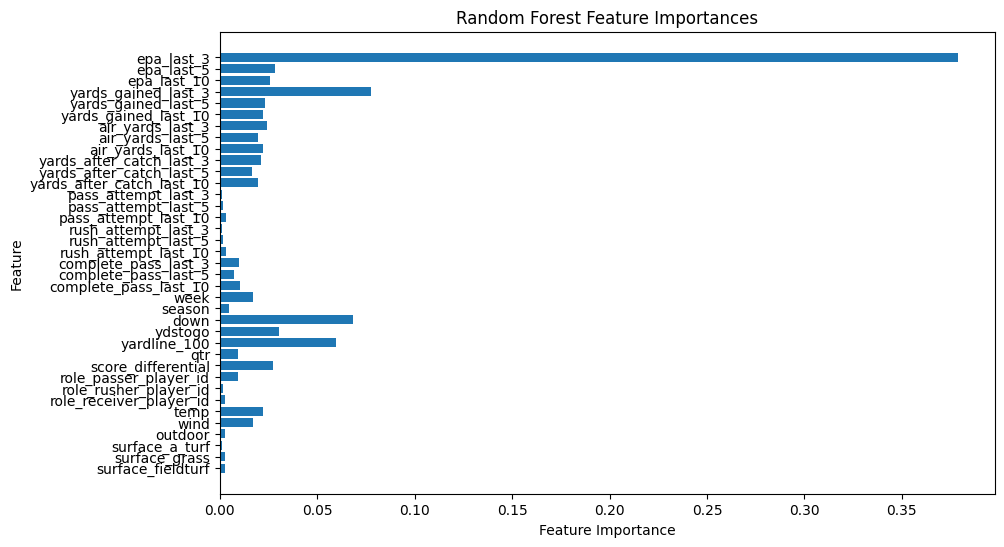

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(contextual_features, rf_model.feature_importances_)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis() # To display the most important feature at the top
plt.show()

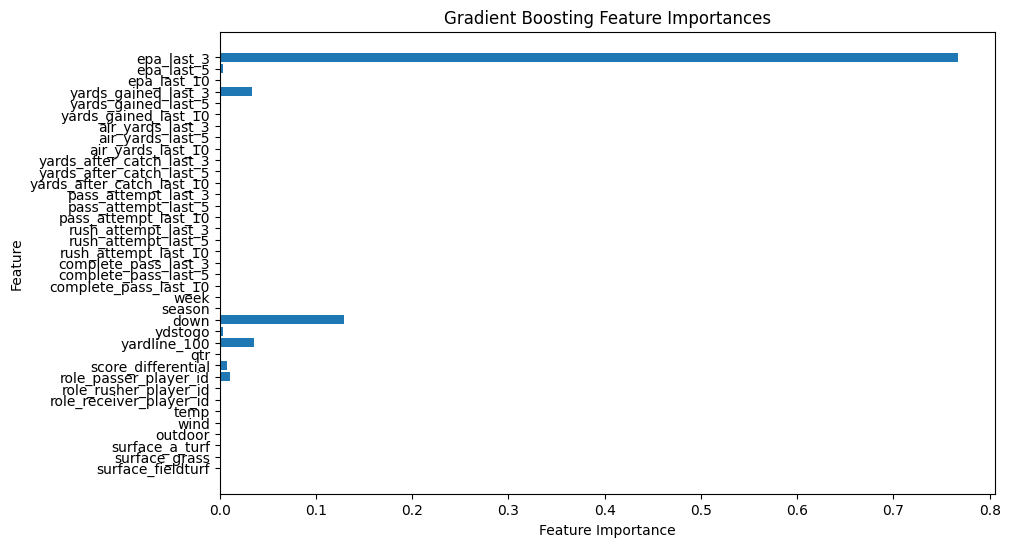

In [13]:
plt.figure(figsize=(10, 6))
plt.barh(contextual_features, gb_model.feature_importances_)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importances")
plt.gca().invert_yaxis() # To display the most important feature at the top
plt.show()

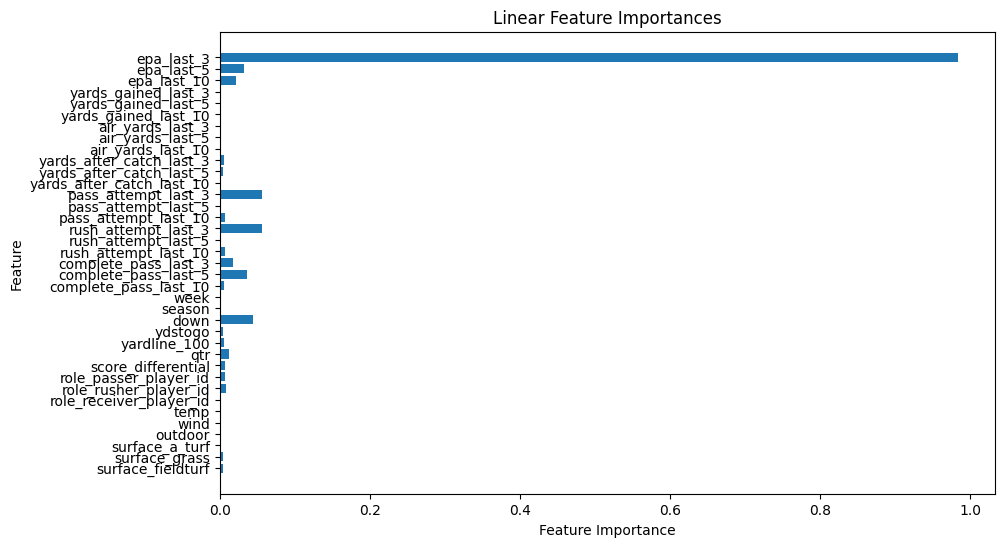

In [15]:
plt.figure(figsize=(10, 6))
plt.barh(contextual_features, np.abs(linear_model.coef_))
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Linear Feature Importances")
plt.gca().invert_yaxis() # To display the most important feature at the top
plt.show()

In [62]:
# Get what player the user wants to analyze
player_name = input("Give me players name (Ex. C.Lamb, G.Kittle)")
while len(player_name) == 0:
  player_name = input("Try again! Wrong players name (Ex. C.Lamb, G.Kittle)")
player_team = input("Give me players team (Ex. DAL, ARI, SF, DET)")
while len(player_team) == 0:
  player_team = input("Try again! Wrong players team (Ex. DAL, ARI, SF, DET)")
player_position = input("Give me players position (Ex. WR, RB, QB, D, K, P)")
while player_position not in {"WR", "RB", "QB", "D", "K", "P"}:
  player_position = input("Try again! Wrong players position (Ex. WR, RB, QB, D, K, P)")


Give me players name (Ex. C.Lamb, G.Kittle)D.Prescott
Give me players team (Ex. DAL, ARI, SF, DET)DAL
Give me players position (Ex. WR, RB, QB, D, K, P)QB


In [67]:
# Get player info
player_data = nfl_data[(nfl_data['passer'] == player_name) | (nfl_data['receiver'] == player_name) | (nfl_data['rusher'] == player_name)]
player_data.head()

,receiver,receiving_yards,yards_after_catch,pass_touchdown,pass_attempt,complete_pass,week,rusher,rush_attempt,rushing_yards,rush_touchdown,fumble,passer,incomplete_pass,passing_yards,pass_touchdown,interception,sack,air_yards,kicker_player_name,tackled_for_loss,solo_tackle,assist_tackle,fumble_forced,fumble_recovery_1_player_name,fumble_recovery_2_player_name,punt_returner_player_name,punter_player_name,return_yards,epa,cpoe,surface,wind,temp,weather,year,posteam_type,defrank,outdoor,rain/snow,field_goal_result_blocked,field_goal_result_made,field_goal_result_missed,extra_point_result_blocked,extra_point_result_failed,extra_point_result_good
2678,D.Schultz,7.0,4.0,0.0,1.0,1.0,1.0,missing_value,0.0,0.0,0.0,0.0,D.Prescott,0.0,7.0,0.0,0.0,0.0,3.0,missing_value,0.0,1.0,0.0,0.0,missing_value,missing_value,missing_value,missing_value,0.0,0.349317,18.361396,matrixturf,0.0,0.0,missing_value,2022.0,home,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2681,D.Houston,11.0,6.0,0.0,1.0,1.0,1.0,missing_value,0.0,0.0,0.0,0.0,D.Prescott,0.0,11.0,0.0,0.0,0.0,5.0,missing_value,0.0,1.0,0.0,0.0,missing_value,missing_value,missing_value,missing_value,0.0,0.410971,18.871999,matrixturf,0.0,0.0,missing_value,2022.0,home,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2682,C.Lamb,16.0,0.0,0.0,1.0,1.0,1.0,missing_value,0.0,0.0,0.0,0.0,D.Prescott,0.0,16.0,0.0,0.0,0.0,16.0,missing_value,0.0,1.0,0.0,0.0,missing_value,missing_value,missing_value,missing_value,0.0,2.322364,33.022851,matrixturf,0.0,0.0,missing_value,2022.0,home,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2685,C.Lamb,0.0,0.0,0.0,1.0,0.0,1.0,missing_value,0.0,0.0,0.0,0.0,D.Prescott,1.0,0.0,0.0,0.0,0.0,6.0,missing_value,0.0,0.0,0.0,0.0,missing_value,missing_value,missing_value,missing_value,0.0,-0.541043,-81.112355,matrixturf,0.0,0.0,missing_value,2022.0,home,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2687,N.Brown,9.0,5.0,0.0,1.0,1.0,1.0,missing_value,0.0,0.0,0.0,0.0,D.Prescott,0.0,9.0,0.0,0.0,0.0,4.0,missing_value,0.0,0.0,1.0,0.0,missing_value,missing_value,missing_value,missing_value,0.0,2.008100,24.714732,matrixturf,0.0,0.0,missing_value,2022.0,home,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Add defense rankings for each game
def_rank_2022 = [['SF', 1], ['DAL', 2], ['NE', 3], ['WAS', 4], ['PHI', 5], ['NO', 6], ['DEN', 7], ['NYJ', 8], ['BUF', 9], ['CIN', 10], ['TB', 11], ['IND', 12], ['JAX', 13], ['BAL', 14],
                 ['KC', 15], ['HOU', 16], ['TEN', 17], ['LAC', 18], ['MIA', 19], ['CAR', 20], ['ARI', 21], ['SEA', 22], ['LA', 23], ['CLE', 24], ['MIN', 25], ['PIT', 26], ['GB', 27],
                 ['NYG', 28], ['LV', 29], ['ATL', 30], ['DET', 31], ['CHI', 32]]
def_rank_2023 = [['SF', 8], ['DAL', 4], ['NE', 7], ['WAS', 31], ['PHI', 30], ['NO', 5], ['DEN', 27], ['NYJ', 3], ['BUF', 9], ['CIN', 28], ['TB', 19], ['IND', 22], ['JAX', 14], ['BAL', 2],
                 ['KC', 6], ['HOU', 15], ['TEN', 26], ['LAC', 25], ['MIA', 16], ['CAR', 24], ['ARI', 32], ['SEA', 29], ['LA', 20], ['CLE', 1], ['MIN', 18], ['PIT', 10], ['GB', 23],
                 ['NYG', 21], ['LV', 11], ['ATL', 12], ['DET', 17], ['CHI', 13]]
def_rank_2024 = [['SF', 23], ['DAL', 30], ['NE', 29], ['WAS', 17], ['PHI', 2], ['NO', 24], ['DEN', 1], ['NYJ', 21], ['BUF', 12], ['CIN', 22], ['TB', 19], ['IND', 13], ['JAX', 31], ['BAL', 8],
                 ['KC', 18], ['HOU', 4], ['TEN', 20], ['LAC', 6], ['MIA', 9], ['CAR', 32], ['ARI', 26], ['SEA', 11], ['LA', 25], ['CLE', 14], ['MIN', 3], ['PIT', 10], ['GB', 5],
                 ['NYG', 27], ['LV', 16], ['ATL', 28], ['DET', 7], ['CHI', 15]]
# 2022 defense
nfl_data['defrank'] = 0
index = 0
for val in nfl_data['defteam']:
  for team, rank in def_rank_2022:
    if val == team:
      nfl_data.loc[index, "defrank"] = rank
  index+=1

nfl_data.drop(columns=['defteam'], inplace=True)

nfl_data.info()

NameError: name 'data_2022' is not defined